<a href="https://colab.research.google.com/github/zakirangwala/esrb-wizard/blob/main/notebooks/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Do Players Prefer Games with Mature Content?**

Regression: can we predict how many minutes a game will have been played in the past two weeks

# Loading Dataset

In [10]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import sklearn
import ast

In [11]:
#loading the dataset (originally from https://www.kaggle.com/datasets/fronkongames/steam-games-dataset; had to manually add a comma to separate Discount and DLC)
from google.colab import drive
drive.mount('/content/drive')

#load data
reg_df = pd.read_csv("/content/drive/MyDrive/CP322/regression.csv") # save to github: notebooks/regression.ipynb

print(reg_df.shape)
reg_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(2739, 122)


,Peak CCU,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Achievements,...,sexual_content,sexual_themes,simulated_gambling,strong_janguage,strong_sexual_content,suggestive_themes,use_of_alcohol,use_of_drugs_and_alcohol,violence,esrb_available
0,2164,59.99,0,5,1,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
1,7571,59.99,0,15,1,0,0,0,0,178,...,0,0,0,0,0,0,0,0,0,0
2,49,3.49,0,0,1,0,0,89,0,0,...,0,0,0,0,0,0,0,0,0,0
3,133,2.99,0,1,1,1,1,0,0,35,...,0,0,0,0,0,0,0,0,0,0
4,358,23.99,0,11,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
#define target and features
TARGET_COL = "Average playtime two weeks"

#columns that leak "Average playtime two weeks"

leak_cols = [
    "played_before",
    "Publishers",
]

cols_to_drop = [TARGET_COL] + [c for c in leak_cols if c in reg_df.columns]

#drop rows where average playtime does not allow for 8 hours of sleep a night
#deal with outliers and new games possibly
#reg_df.drop(reg_df[reg_df["Average playtime two weeks"] > 15120].index, inplace=True)

#drop target, IDs, and leakage columns
X = reg_df.drop(columns=cols_to_drop, errors="ignore")
y = reg_df[TARGET_COL].astype(int)
reg_df = reg_df.drop(columns=[c for c in leak_cols if c in reg_df.columns], errors="ignore")

#keep only numeric columns
numeric_cols = X.select_dtypes(include=[np.number]).columns
X = X[numeric_cols]

print("Final feature columns:", list(numeric_cols))
print("X shape:", X.shape)
print("y value counts:")
print(y.value_counts())

reg_df.head()

y_min = y.min()
y_max = y.max()

y_min_log = np.log1p(y).min()
y_max_log = np.log1p(y).max()

Final feature columns: ['Peak CCU', 'Price', 'Discount', 'DLC count', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'User score', 'Achievements', 'Recommendations', 'release_year', 'midpoint_estimated_owners', 'esrb_age', 'voice_acting', '%_positive_reviews', '360 Video', 'Accounting', 'Action', 'Adventure', 'Animation & Modeling', 'Audio Production', 'Casual', 'Design & Illustration', 'Documentary', 'Early Access', 'Education', 'Episodic', 'Game Development', 'Indie', 'Massively Multiplayer', 'Movie', 'Photo Editing', 'RPG', 'Racing', 'Short', 'Simulation', 'Software Training', 'Sports', 'Strategy', 'Tutorial', 'Utilities', 'Video Production', 'Web Publishing', 'Captions available', 'Co-op', 'Commentary available', 'Cross-Platform Multiplayer', 'Family Sharing', 'Full controller support', 'HDR available', 'In-App Purchases', 'Includes Source SDK', 'Includes level editor', 'LAN Co-op', 'LAN PvP', 'MMO', 'Mods', 'Mods (require HL2)', 'Multi-player', 'Online Co-op', 'Online PvP', 'Parti


Distribution of Average playtime two weeks:
count     2739.000000
mean       369.035049
std        923.907960
min          1.000000
25%         27.000000
50%        104.000000
75%        378.000000
max      10996.000000
Name: Average playtime two weeks, dtype: float64


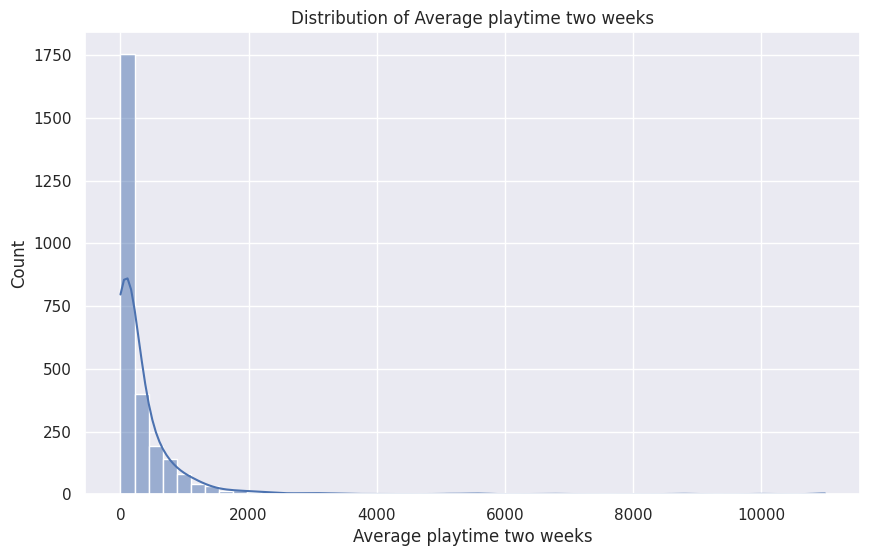

In [13]:
print(f"\nDistribution of {TARGET_COL}:")
print(reg_df[TARGET_COL].describe())
plt.figure(figsize=(10, 6))
sns.histplot(reg_df[TARGET_COL], bins=50, kde=True)
plt.title(f'Distribution of {TARGET_COL}')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.show()


Distribution of np.log1p(Average playtime two weeks):


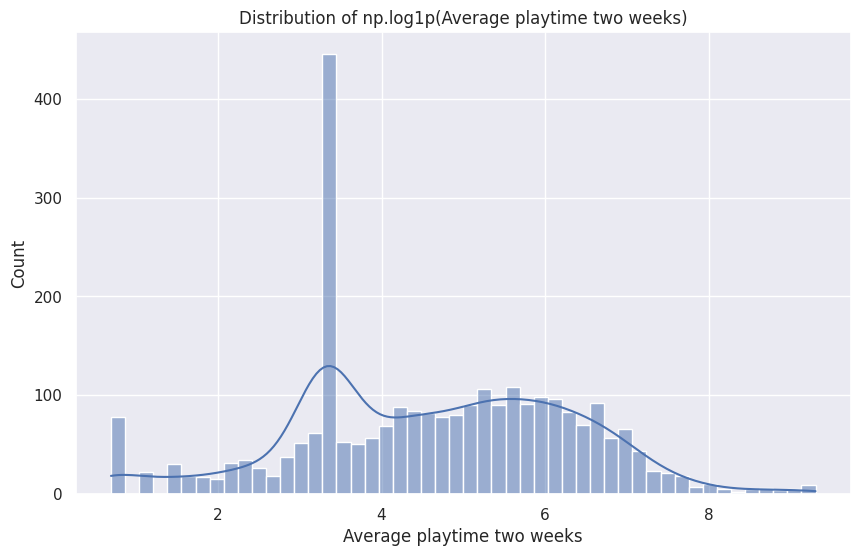

In [14]:
print(f"\nDistribution of np.log1p({TARGET_COL}):")
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(reg_df[TARGET_COL]), bins=50, kde=True)
plt.title(f'Distribution of np.log1p({TARGET_COL})')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.show()

# Splitting Data into Train/Test/Split

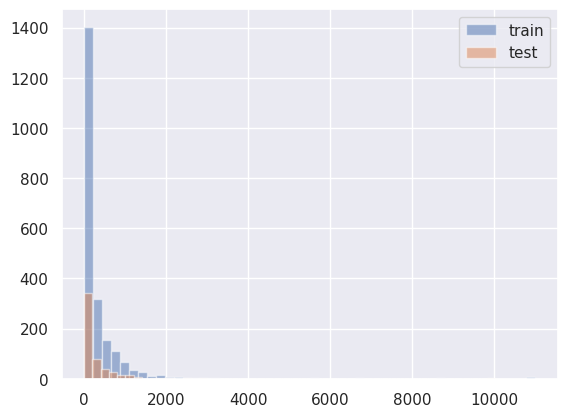

In [15]:
from sklearn.model_selection import train_test_split

# Create quantile bins (e.g., deciles)
reg_df["target_bin"] = pd.qcut(y, q=10, labels=False, duplicates="drop")

# train vs test
train_df, test_df = train_test_split(
    reg_df, test_size=0.2, stratify=reg_df["target_bin"], random_state=42
)

# Drop helper column
for d in [train_df, test_df]:
    d.drop(columns=["target_bin"], inplace=True)


plt.hist(train_df[TARGET_COL], bins=50, alpha=0.5, label='train')
plt.hist(test_df[TARGET_COL], bins=50, alpha=0.5, label='test')
plt.legend()
plt.show()

X_train = train_df.drop(columns=TARGET_COL)
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=TARGET_COL)
y_test = test_df[TARGET_COL]

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

By training on log1p(y) skew is reduced so that the model treats large and small playtimes more evenly and feature importance reflects factors affecting typical behavior rather than extreme outliers

# Importing Performance Metrics

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    average_precision_score,
    precision_recall_curve,
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

# Dataframe to compare performance metrics on classifier models
regression_performance_data = {'Metric': ['MSE',
                                          'RMSE',
                                          'R2',
                                          'MAE']}

reg_performance = pd.DataFrame(regression_performance_data)
reg_performance = reg_performance.set_index('Metric')

print("log1p min: ", np.log1p(reg_df[TARGET_COL]).min())
print("log1p max: ", np.log1p(reg_df[TARGET_COL]).max())

log1p min:  0.6931471805599453
log1p max:  9.305377787310935


#XGBoost

## Basic (No transformation)

In [17]:
pip install optuna

In [18]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict

# check model fit based on cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def xgboostObjective(trial):
    # paramaters to hypertune
    eval_metric = trial.suggest_categorical("eval_metric", ["rmse", "mae", "rmsle"])
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 3, 7)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    subsample = trial.suggest_float("subsample", 0.6, 0.9)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 0.8)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 5)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    # xgboost classifier
    reg_xgb = XGBRegressor(
        objective="reg:squarederror",
        eval_metric=eval_metric,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        max_delta_step=max_delta_step,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
    )

    # MSE is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(reg_xgb, X_train, y_train, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgboostObjective, n_trials=50) #increase if have time
best_params_xgb = study_xgb.best_params

# print best parameters
print("Best hyperparameters:", best_params_xgb)
print("Best negative MSE:", study_xgb.best_value)

[I 2025-11-24 18:27:31,979] A new study created in memory with name: no-name-37221063-6d05-4e16-88df-8c5664af64db
[I 2025-11-24 18:27:38,054] Trial 0 finished with value: -875417.6625 and parameters: {'eval_metric': 'rmse', 'n_estimators': 159, 'max_depth': 5, 'min_child_weight': 4, 'gamma': 2.5709193023555477, 'max_delta_step': 7, 'learning_rate': 0.04672069196782313, 'subsample': 0.6744903885251591, 'colsample_bytree': 0.7162151375059658, 'reg_alpha': 2.7111794561235336, 'reg_lambda': 2.548726850402332}. Best is trial 0 with value: -875417.6625.
[I 2025-11-24 18:27:43,774] Trial 1 finished with value: -885487.9875 and parameters: {'eval_metric': 'rmsle', 'n_estimators': 55, 'max_depth': 5, 'min_child_weight': 7, 'gamma': 2.989433198455498, 'max_delta_step': 4, 'learning_rate': 0.04731262943348961, 'subsample': 0.6134174531218606, 'colsample_bytree': 0.7300726184154493, 'reg_alpha': 2.688922987089418, 'reg_lambda': 4.38163448601194}. Best is trial 0 with value: -875417.6625.
[I 2025-1

Best hyperparameters: {'eval_metric': 'rmse', 'n_estimators': 156, 'max_depth': 7, 'min_child_weight': 3, 'gamma': 1.6729021482883846, 'max_delta_step': 9, 'learning_rate': 0.08858768046512179, 'subsample': 0.8992760483355572, 'colsample_bytree': 0.7153318956508077, 'reg_alpha': 1.141848809637327, 'reg_lambda': 0.4454809390343832}
Best negative MSE: -858765.75


In [19]:
# refit model based on best parameters
regr_xgb = XGBRegressor(
        objective="reg:squarederror",
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_xgb,
    X_train,
    y_train,
    cv=kf
)

regr_xgb.fit(X_train, y_train)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

# Evaluate test data
y_test_pred = regr_xgb.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

# Store performance for comparison later
reg_performance['XGBoost'] = [
    mean_squared_error(y_test, y_test_pred),
    np.sqrt(mean_squared_error(y_test, y_test_pred)),
    r2_score(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_xgb = y_test_pred


TRAIN METRICS:
MSE: 858853.9375
RMSE: 926.7437280607838
R2: 0.03178000450134277
MAE: 380.3626708984375

TEST METRICS:
MSE: 699840.125
RMSE: 836.5644774911256
R2: 0.025634825229644775
MAE: 371.7908935546875


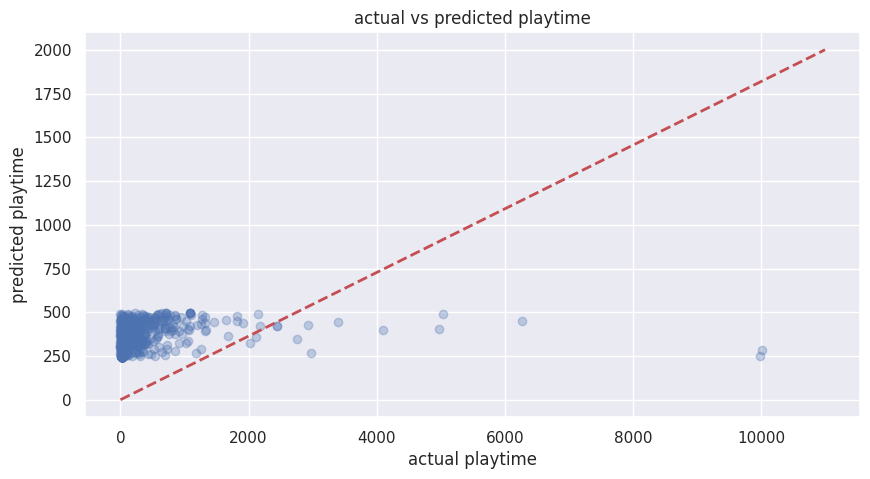

In [20]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [0, 2000], 'r--', lw=2)
plt.xlabel("actual playtime")
plt.ylabel("predicted playtime")
plt.title("actual vs predicted playtime")
plt.show()

## Basic (log1p)

In [21]:
from xgboost import XGBRegressor

def xgboostObjective(trial):
    # paramaters to hypertune
    eval_metric = trial.suggest_categorical("eval_metric", ["rmse", "mae", "rmsle"])
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 3, 7)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    subsample = trial.suggest_float("subsample", 0.6, 0.9)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 0.8)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 5)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    # xgboost classifier
    reg_xgb_log = XGBRegressor(
        objective="reg:squarederror",
        eval_metric=eval_metric,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        max_delta_step=max_delta_step,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
    )

    # MSE is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(reg_xgb_log, X_train, y_train_log, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
reg_xgb_log = optuna.create_study(direction="maximize")
reg_xgb_log.optimize(xgboostObjective, n_trials=50) #increase if have time
best_params_xgb = reg_xgb_log.best_params

# print best parameters
print("Best hyperparameters:", best_params_xgb)
print("Best negative MSE:", reg_xgb_log.best_value)

[I 2025-11-24 18:29:14,228] A new study created in memory with name: no-name-046a8486-2fe9-4c62-bf62-911a4485a31e
[I 2025-11-24 18:29:22,657] Trial 0 finished with value: -2.0187873602909647 and parameters: {'eval_metric': 'mae', 'n_estimators': 97, 'max_depth': 6, 'min_child_weight': 7, 'gamma': 3.7441676471132124, 'max_delta_step': 6, 'learning_rate': 0.013715969183322265, 'subsample': 0.8373586816388153, 'colsample_bytree': 0.6278787375444617, 'reg_alpha': 0.8133427004881155, 'reg_lambda': 3.3469575224095607}. Best is trial 0 with value: -2.0187873602909647.
[I 2025-11-24 18:29:26,191] Trial 1 finished with value: -1.9339663663884523 and parameters: {'eval_metric': 'rmse', 'n_estimators': 75, 'max_depth': 4, 'min_child_weight': 5, 'gamma': 3.4219072827718593, 'max_delta_step': 0, 'learning_rate': 0.0537319446556077, 'subsample': 0.6723577068162114, 'colsample_bytree': 0.6695381531414007, 'reg_alpha': 0.9822313093860907, 'reg_lambda': 8.480827269443004}. Best is trial 1 with value: -

Best hyperparameters: {'eval_metric': 'rmsle', 'n_estimators': 168, 'max_depth': 7, 'min_child_weight': 3, 'gamma': 0.07614727460551762, 'max_delta_step': 1, 'learning_rate': 0.02267511973386916, 'subsample': 0.8457855370258615, 'colsample_bytree': 0.7203732125444907, 'reg_alpha': 2.8180236503253164, 'reg_lambda': 2.159412875482646}
Best negative MSE: -1.8817534816320634


Best hyperparameters: {'eval_metric': 'mae', 'n_estimators': 193, 'max_depth': 7, 'min_child_weight': 3, 'gamma': 0.5172732288258364, 'max_delta_step': 0, 'learning_rate': 0.027560536513400923, 'subsample': 0.8923697535139294, 'colsample_bytree': 0.7595714852395946, 'reg_alpha': 1.5018208197138516, 'reg_lambda': 9.292609920015266}
Best negative MSE: -1.8791862282227032

In [22]:
# refit model based on best parameters
regr_xgb_log = XGBRegressor(
        objective="reg:squarederror",
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_xgb_log,
    X_train,
    y_train_log,
    cv=kf
)

regr_xgb_log.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_xgb_log.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['XGB (log1p)'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_xgb_log = y_test_pred


TRAIN METRICS:
MSE: 1.8817135582749296
RMSE: 1.3717556481658566
R2: 0.3472840164789961
MAE: 0.9570522504542021

TEST METRICS:
MSE: 2.0376605671696852
RMSE: 1.427466485480372
R2: 0.29121016813316103
MAE: 0.9927185696056183


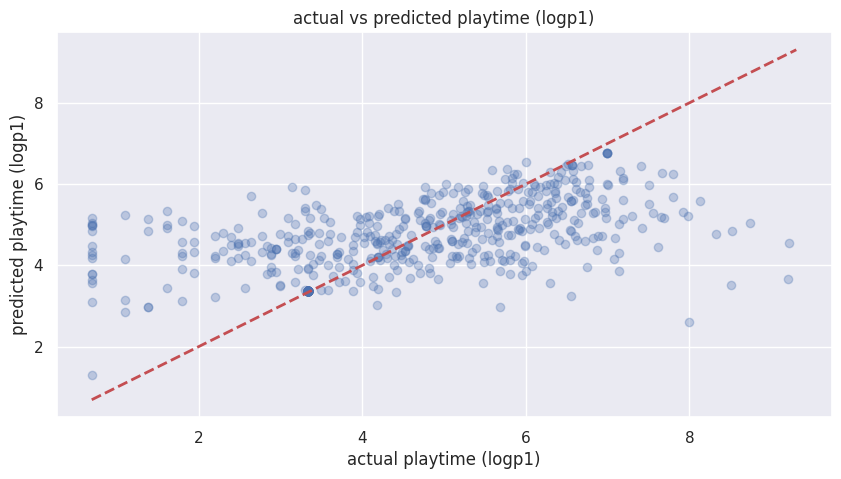

In [23]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_test_pred, alpha=0.3)
plt.plot([np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()],
         [np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()], 'r--', lw=2)
plt.xlabel("actual playtime (logp1)")
plt.ylabel("predicted playtime (logp1)")
plt.title("actual vs predicted playtime (logp1)")
plt.show()

# LightGBM

## Basic (no transformation)

In [24]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

def lightGBMObjective(trial):
    # paramaters to hypertune
    n_estimators = trial.suggest_int("n_estimators", 25, 200)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    num_leaves = trial.suggest_int("num_leaves", 5, 45)
    max_depth = trial.suggest_int("max_depth", 1, 15)
    min_child_samples = trial.suggest_int("min_child_samples", 20, 200)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)
    bagging_fraction = trial.suggest_float("bagging_fraction", 0.6, 0.8)
    feature_fraction = trial.suggest_float("feature_fraction", 0.6, 0.9)

    # lightgbm regression
    regr = LGBMRegressor(
        boosting_type="gbdt",
        n_estimators=n_estimators,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        max_depth=max_depth,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        bagging_fraction=bagging_fraction,
        feature_fraction=feature_fraction,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # precision is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(regr, X_train, y_train, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_light = optuna.create_study(direction="minimize")
study_light.optimize(lightGBMObjective, n_trials=50) #increase if have time
best_params_light = study_light.best_params

# print best parameters
print("Best hyperparameters:", best_params_light)
print("Best average precision:", study_light.best_value)

[I 2025-11-24 18:31:01,105] A new study created in memory with name: no-name-1c29c8c3-371a-45c1-b974-25d86024c31a
[I 2025-11-24 18:31:01,400] Trial 0 finished with value: -841081.7771195952 and parameters: {'n_estimators': 105, 'learning_rate': 0.07259321478210508, 'num_leaves': 7, 'max_depth': 4, 'min_child_samples': 126, 'reg_alpha': 0.5084828707893805, 'reg_lambda': 3.146499499093162, 'bagging_fraction': 0.659511517545983, 'feature_fraction': 0.760809379424493}. Best is trial 0 with value: -841081.7771195952.
[I 2025-11-24 18:31:01,620] Trial 1 finished with value: -829476.3668272143 and parameters: {'n_estimators': 48, 'learning_rate': 0.09395517578626458, 'num_leaves': 39, 'max_depth': 6, 'min_child_samples': 66, 'reg_alpha': 0.07914357157905705, 'reg_lambda': 2.866738891219902, 'bagging_fraction': 0.6932241360046831, 'feature_fraction': 0.760825827153525}. Best is trial 0 with value: -841081.7771195952.
[I 2025-11-24 18:31:01,790] Trial 2 finished with value: -852044.0701321863 a

Best hyperparameters: {'n_estimators': 25, 'learning_rate': 0.011895337267817434, 'num_leaves': 5, 'max_depth': 15, 'min_child_samples': 198, 'reg_alpha': 0.2991883613941256, 'reg_lambda': 1.077719571203534, 'bagging_fraction': 0.763888093579882, 'feature_fraction': 0.6554798268209463}
Best average precision: -874000.7301025083


In [25]:
# refit model based on best parameters
regr_light = LGBMRegressor(
        boosting_type="gbdt",
        **best_params_light,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_light,
    X_train,
    y_train,
    cv=kf
)

regr_light.fit(X_train, y_train)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

# Evaluate test data
y_test_pred = regr_light.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

# Store performance for comparison later
reg_performance['LightGBM'] = [
    mean_squared_error(y_test, y_test_pred),
    np.sqrt(mean_squared_error(y_test, y_test_pred)),
    r2_score(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred)
]

# to draw PR_AUC later on
y_test_pred_light = y_test_pred


TRAIN METRICS:
MSE: 874090.6773161126
RMSE: 934.9281669284077
R2: 0.01460305392361938
MAE: 403.2189705313113

TEST METRICS:
MSE: 707481.0334564112
RMSE: 841.1189175475791
R2: 0.01499660685517823
MAE: 392.4774881679535


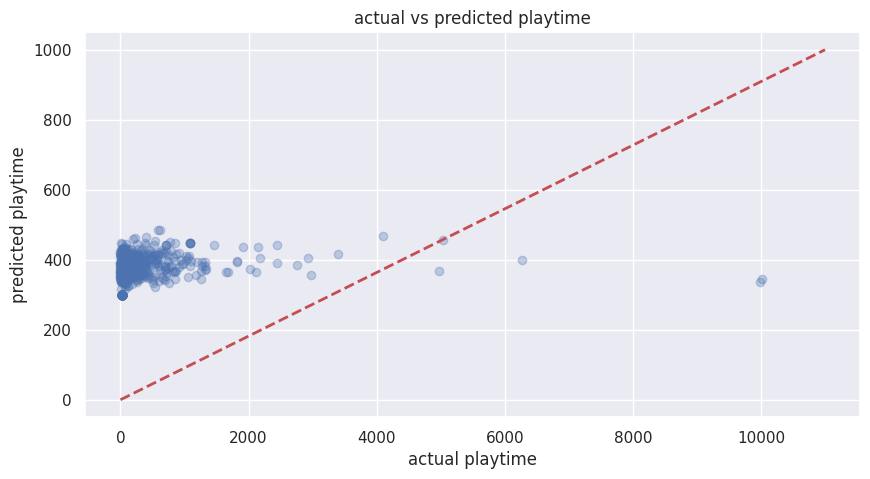

In [26]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y.min(), y.max()],
         [0, 1000], 'r--', lw=2)
plt.xlabel("actual playtime")
plt.ylabel("predicted playtime")
plt.title("actual vs predicted playtime")
plt.show()

## Basic (log1p)

In [27]:
def lightGBMObjective(trial):
    # paramaters to hypertune
    n_estimators = trial.suggest_int("n_estimators", 25, 200)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    num_leaves = trial.suggest_int("num_leaves", 5, 45)
    max_depth = trial.suggest_int("max_depth", 1, 15)
    min_child_samples = trial.suggest_int("min_child_samples", 20, 200)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)
    bagging_fraction = trial.suggest_float("bagging_fraction", 0.6, 0.8)
    feature_fraction = trial.suggest_float("feature_fraction", 0.6, 0.9)

    # lightgbm regression
    regr = LGBMRegressor(
        boosting_type="gbdt",
        n_estimators=n_estimators,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        max_depth=max_depth,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        bagging_fraction=bagging_fraction,
        feature_fraction=feature_fraction,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # precision is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(regr, X_train, y_train_log, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_light = optuna.create_study(direction="minimize")
study_light.optimize(lightGBMObjective, n_trials=50) #increase if have time
best_params_light = study_light.best_params

# print best parameters
print("Best hyperparameters:", best_params_light)
print("Best average precision:", study_light.best_value)

[I 2025-11-24 18:31:19,082] A new study created in memory with name: no-name-092daf10-af66-4d1e-8e28-a7fb5dd70838
[I 2025-11-24 18:31:20,264] Trial 0 finished with value: -1.9482658341555315 and parameters: {'n_estimators': 108, 'learning_rate': 0.09099795370939562, 'num_leaves': 41, 'max_depth': 5, 'min_child_samples': 142, 'reg_alpha': 0.9991267272125798, 'reg_lambda': 5.439090507020725, 'bagging_fraction': 0.6352040002070167, 'feature_fraction': 0.6941473152388815}. Best is trial 0 with value: -1.9482658341555315.
[I 2025-11-24 18:31:21,028] Trial 1 finished with value: -1.9365635986999732 and parameters: {'n_estimators': 134, 'learning_rate': 0.03760475901180886, 'num_leaves': 13, 'max_depth': 4, 'min_child_samples': 86, 'reg_alpha': 0.025125811223806083, 'reg_lambda': 9.651176207162216, 'bagging_fraction': 0.7248903426107721, 'feature_fraction': 0.7930946148644624}. Best is trial 0 with value: -1.9482658341555315.
[I 2025-11-24 18:31:21,506] Trial 2 finished with value: -1.9758753

Best hyperparameters: {'n_estimators': 25, 'learning_rate': 0.01285791669415524, 'num_leaves': 45, 'max_depth': 1, 'min_child_samples': 197, 'reg_alpha': 0.7723440360181588, 'reg_lambda': 4.125218428074007, 'bagging_fraction': 0.7955173245647951, 'feature_fraction': 0.6004587416469781}
Best average precision: -2.6672980263564954


In [28]:
# refit model based on best parameters
regr_light_log = LGBMRegressor(
        boosting_type="gbdt",
        **best_params_light,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_light_log,
    X_train,
    y_train_log,
    cv=kf
)

regr_light_log.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_light_log.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['LGBM (log1p)'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# to draw PR_AUC later on
y_test_pred_light_log = y_test_pred


TRAIN METRICS:
MSE: 2.6671991892607037
RMSE: 1.6331562047950905
R2: 0.07482011042067183
MAE: 1.337200123624171

TEST METRICS:
MSE: 2.639739277537621
RMSE: 1.6247274471546362
R2: 0.08178016061966953
MAE: 1.3329406707652298


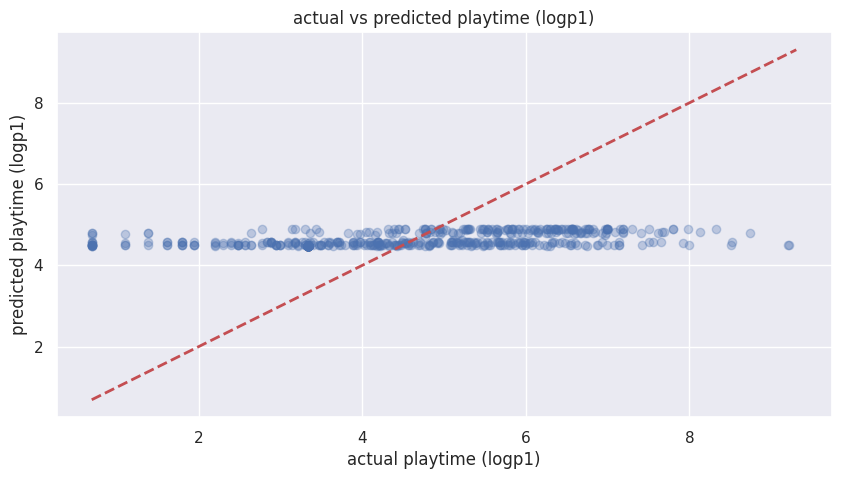

In [29]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_test_pred, alpha=0.3)
plt.plot([np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()],
         [np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()], 'r--', lw=2)
plt.xlabel("actual playtime (logp1)")
plt.ylabel("predicted playtime (logp1)")
plt.title("actual vs predicted playtime (logp1)")
plt.show()

# Removing outliers of response variable

In [30]:
# Computing IQR
Q1 = np.percentile(reg_df[TARGET_COL], 25)
Q3 = np.percentile(reg_df[TARGET_COL], 75)
IQR = Q3 - Q1
IQR

# Defining the bounds for the Price feature
lower = Q1 - 3*IQR
upper = Q3 + 3*IQR

# Removing any rows where price is outside the bounds
reg_df = reg_df[(reg_df[TARGET_COL] >= lower) & (reg_df[TARGET_COL] <= upper)]

X = reg_df.drop(columns=TARGET_COL, errors="ignore")
y = reg_df[TARGET_COL].astype(int)

y_min_iqr = y.min()
y_max_iqr = y.max()

y_min_IQR_log = np.log1p(y).min()
y_max_IQR_log = np.log1p(y).max()


Distribution of Average playtime two weeks:
count    2625.000000
mean      228.811810
std       296.976699
min         1.000000
25%        27.000000
50%        91.000000
75%       322.000000
max      1430.000000
Name: Average playtime two weeks, dtype: float64


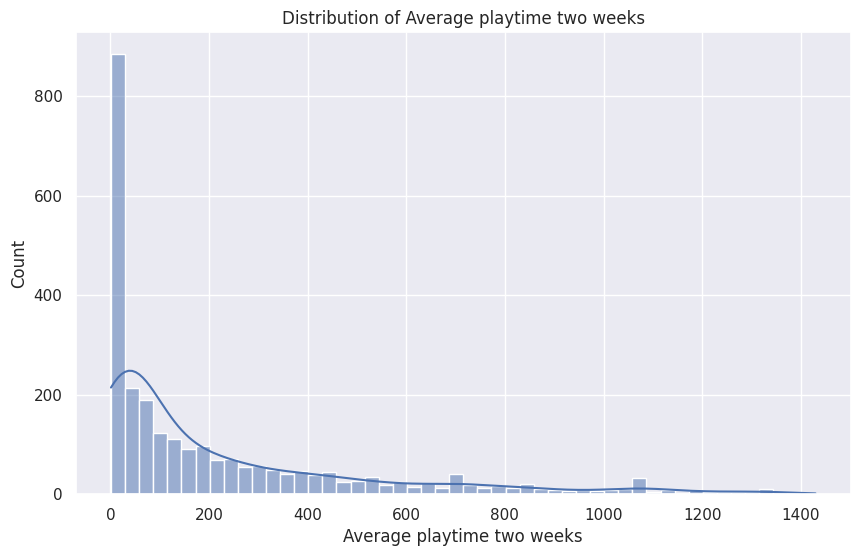

In [31]:
print(f"\nDistribution of {TARGET_COL}:")
print(reg_df[TARGET_COL].describe())
plt.figure(figsize=(10, 6))
sns.histplot(reg_df[TARGET_COL], bins=50, kde=True)
plt.title(f'Distribution of {TARGET_COL}')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.show()


Distribution of np.log1p(Average playtime two weeks):


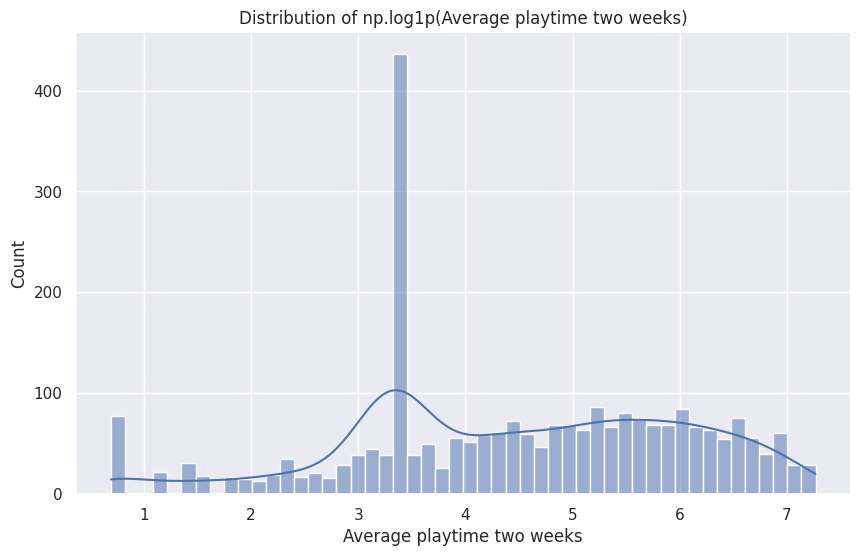

In [32]:
print(f"\nDistribution of np.log1p({TARGET_COL}):")
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(reg_df[TARGET_COL]), bins=50, kde=True)
plt.title(f'Distribution of np.log1p({TARGET_COL})')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.show()

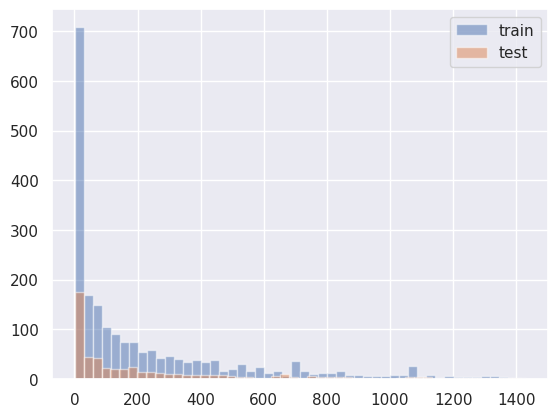

In [33]:
from sklearn.model_selection import train_test_split

# Create quantile bins (e.g., deciles)
reg_df["target_bin"] = pd.qcut(y, q=25, labels=False, duplicates="drop")

# train vs test
train_df, test_df = train_test_split(
    reg_df, test_size=0.2, stratify=reg_df["target_bin"], random_state=42
)

# Drop helper column
for d in [train_df, test_df]:
    d.drop(columns=["target_bin"], inplace=True)


plt.hist(train_df[TARGET_COL], bins=50, alpha=0.5, label='train')
plt.hist(test_df[TARGET_COL], bins=50, alpha=0.5, label='test')
plt.legend()
plt.show()

X_train = train_df.drop(columns=TARGET_COL)
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=TARGET_COL)
y_test = test_df[TARGET_COL]

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# XGBoost (IQR)

## Basic (No transformation)

In [34]:
# check model fit based on cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def xgboostObjective(trial):
    # paramaters to hypertune
    eval_metric = trial.suggest_categorical("eval_metric", ["rmse", "mae", "rmsle"])
    n_estimators = trial.suggest_int("n_estimators", 200, 1500)
    max_depth = trial.suggest_int("max_depth", 3, 7)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    subsample = trial.suggest_float("subsample", 0.6, 0.9)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 0.8)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 5)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    # xgboost classifier
    reg_xgb = XGBRegressor(
        objective="reg:squarederror",
        eval_metric=eval_metric,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        max_delta_step=max_delta_step,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
    )

    # MSE is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(reg_xgb, X_train, y_train, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgboostObjective, n_trials=50) #increase if have time
best_params_xgb = study_xgb.best_params

# print best parameters
print("Best hyperparameters:", best_params_xgb)
print("Best negative MSE:", study_xgb.best_value)

[I 2025-11-24 18:31:34,676] A new study created in memory with name: no-name-a0786bf4-303c-482b-8ba2-b2b6734838cf
[I 2025-11-24 18:31:35,397] Trial 0 finished with value: -84476.0953125 and parameters: {'eval_metric': 'rmse', 'n_estimators': 103, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 4.411452648106384, 'max_delta_step': 8, 'learning_rate': 0.012905127658611269, 'subsample': 0.7201115077055645, 'colsample_bytree': 0.6655579048580884, 'reg_alpha': 4.812774492277445, 'reg_lambda': 3.5341449182723483}. Best is trial 0 with value: -84476.0953125.
[I 2025-11-24 18:31:36,344] Trial 1 finished with value: -84884.6671875 and parameters: {'eval_metric': 'mae', 'n_estimators': 109, 'max_depth': 5, 'min_child_weight': 2, 'gamma': 4.265210796666477, 'max_delta_step': 1, 'learning_rate': 0.07682914131376577, 'subsample': 0.6730685692512168, 'colsample_bytree': 0.6426830975199367, 'reg_alpha': 2.0075209773365845, 'reg_lambda': 8.575060282559226}. Best is trial 0 with value: -84476.0953125.


Best hyperparameters: {'eval_metric': 'mae', 'n_estimators': 163, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 3.1782182072109686, 'max_delta_step': 0, 'learning_rate': 0.09401583943314559, 'subsample': 0.74838013199083, 'colsample_bytree': 0.6741349143919335, 'reg_alpha': 2.7781575972190753, 'reg_lambda': 9.279667314337619}
Best negative MSE: -60205.68984375


In [35]:
# refit model based on best parameters
regr_xgb_iqr = XGBRegressor(
        objective="reg:squarederror",
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_xgb_iqr,
    X_train,
    y_train,
    cv=kf
)

regr_xgb_iqr.fit(X_train, y_train)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

# Evaluate test data
y_test_pred = regr_xgb_iqr.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

# Store performance for comparison later
reg_performance['XGB IQR'] = [
    mean_squared_error(y_test, y_test_pred),
    np.sqrt(mean_squared_error(y_test, y_test_pred)),
    r2_score(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_xgb_iqr = y_test_pred


TRAIN METRICS:
MSE: 60205.69140625
RMSE: 245.3684808736648
R2: 0.3033760190010071
MAE: 157.37542724609375

TEST METRICS:
MSE: 63905.7734375
RMSE: 252.79591262023996
R2: 0.32780617475509644
MAE: 159.3922576904297


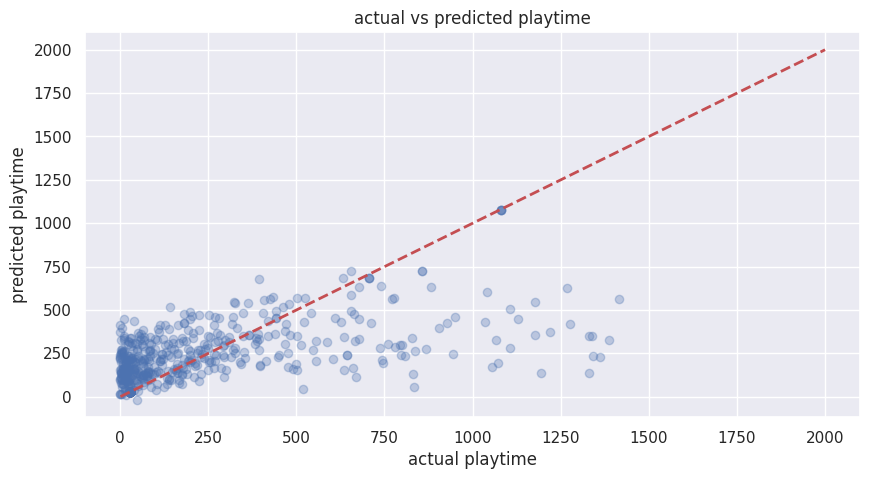

In [36]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y.min(), 2000], [0, 2000], 'r--', lw=2)
plt.xlabel("actual playtime")
plt.ylabel("predicted playtime")
plt.title("actual vs predicted playtime")
plt.show()

## Basic (log1p)

In [81]:
def xgboostObjective(trial):
    # paramaters to hypertune
    n_estimators = trial.suggest_int("n_estimators", 200, 1500)
    max_depth = trial.suggest_int("max_depth", 3, 7)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    subsample = trial.suggest_float("subsample", 0.6, 0.9)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 0.8)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 5)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    # xgboost classifier
    reg_xgb = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        max_delta_step=max_delta_step,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
    )

    # MSE is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(reg_xgb, X_train, y_train_log, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgboostObjective, n_trials=50) #increase if have time
best_params_xgb = study_xgb.best_params

# print best parameters
print("Best hyperparameters:", best_params_xgb)
print("Best negative MSE:", study_xgb.best_value)

[I 2025-11-24 19:25:16,355] A new study created in memory with name: no-name-16193c0d-e19d-4397-9db9-6d5a61990daf
[I 2025-11-24 19:25:19,135] Trial 0 finished with value: -1.9081995327872285 and parameters: {'n_estimators': 786, 'max_depth': 4, 'min_child_weight': 5, 'gamma': 2.235438592223854, 'max_delta_step': 2, 'learning_rate': 0.09909896742487938, 'subsample': 0.7363931078867318, 'colsample_bytree': 0.6056966586876888, 'reg_alpha': 2.4964688075574437, 'reg_lambda': 7.6970129862726955}. Best is trial 0 with value: -1.9081995327872285.
[I 2025-11-24 19:25:32,158] Trial 1 finished with value: -2.12038605095373 and parameters: {'n_estimators': 1388, 'max_depth': 7, 'min_child_weight': 3, 'gamma': 0.18966387569421317, 'max_delta_step': 1, 'learning_rate': 0.07732037798700032, 'subsample': 0.822705162627376, 'colsample_bytree': 0.6978570841182823, 'reg_alpha': 3.0356924351078476, 'reg_lambda': 9.032837590842075}. Best is trial 0 with value: -1.9081995327872285.
[I 2025-11-24 19:25:35,52

Best hyperparameters: {'n_estimators': 521, 'max_depth': 5, 'min_child_weight': 1, 'gamma': 4.665641592967696, 'max_delta_step': 6, 'learning_rate': 0.020548057812620098, 'subsample': 0.7443126765334127, 'colsample_bytree': 0.7067220018011667, 'reg_alpha': 1.668089730059366, 'reg_lambda': 1.8718574075565062}
Best negative MSE: -1.8424456287044713


In [82]:
# refit model based on best parameters
regr_xgb_iqr_log = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_xgb_iqr_log,
    X_train,
    y_train_log,
    cv=kf
)

regr_xgb_iqr_log.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_xgb_iqr_log.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['XGB IQR (log)'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_xgb_iqr_log = y_test_pred


TRAIN METRICS:
MSE: 1.8424456287044715
RMSE: 1.3573671679779467
R2: 0.25914831675581584
MAE: 0.9950121086796235

TEST METRICS:
MSE: 1.7415459341946913
RMSE: 1.3196764505721437
R2: 0.29283998148981705
MAE: 0.9847314393776694


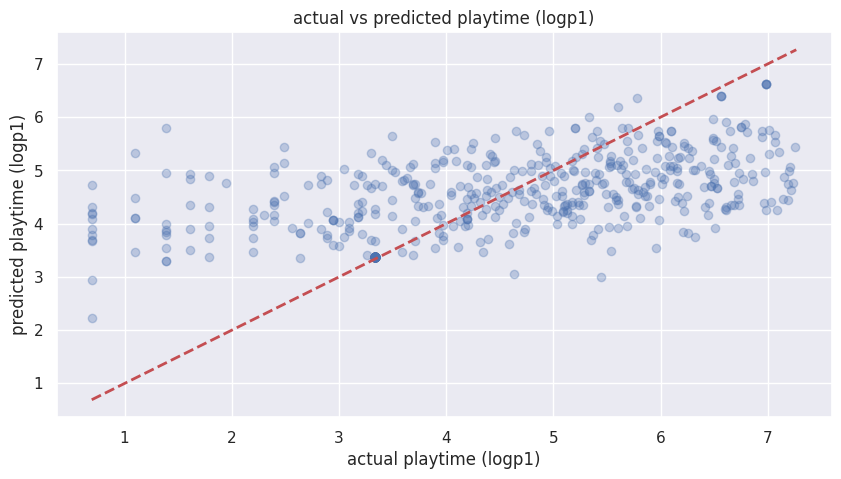

In [83]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_test_pred, alpha=0.3)
plt.plot([np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()],
         [np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()], 'r--', lw=2)
plt.xlabel("actual playtime (logp1)")
plt.ylabel("predicted playtime (logp1)")
plt.title("actual vs predicted playtime (logp1)")
plt.show()

# LightGBM (IQR)

## Basic (No transformation)

In [40]:
def lightGBMObjective(trial):
    # paramaters to hypertune
    n_estimators = trial.suggest_int("n_estimators", 25, 200)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    num_leaves = trial.suggest_int("num_leaves", 5, 45)
    max_depth = trial.suggest_int("max_depth", 1, 15)
    min_child_samples = trial.suggest_int("min_child_samples", 20, 200)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)
    bagging_fraction = trial.suggest_float("bagging_fraction", 0.6, 0.8)
    feature_fraction = trial.suggest_float("feature_fraction", 0.6, 0.9)

    # lightgbm regression
    regr = LGBMRegressor(
        boosting_type="gbdt",
        n_estimators=n_estimators,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        max_depth=max_depth,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        bagging_fraction=bagging_fraction,
        feature_fraction=feature_fraction,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # precision is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(regr, X_train, y_train, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_light = optuna.create_study(direction="minimize")
study_light.optimize(lightGBMObjective, n_trials=50) #increase if have time
best_params_light = study_light.best_params

# print best parameters
print("Best hyperparameters:", best_params_light)
print("Best average precision:", study_light.best_value)

[I 2025-11-24 18:33:59,231] A new study created in memory with name: no-name-33e8bdbe-0445-458b-8ea0-8887f44d3b16
[I 2025-11-24 18:33:59,396] Trial 0 finished with value: -64360.871397512245 and parameters: {'n_estimators': 114, 'learning_rate': 0.08008603092555215, 'num_leaves': 13, 'max_depth': 1, 'min_child_samples': 195, 'reg_alpha': 0.2586572474329114, 'reg_lambda': 0.8363797070557355, 'bagging_fraction': 0.6141818163677687, 'feature_fraction': 0.6847133898121796}. Best is trial 0 with value: -64360.871397512245.
[I 2025-11-24 18:33:59,986] Trial 1 finished with value: -61628.42509632404 and parameters: {'n_estimators': 181, 'learning_rate': 0.0762869607334125, 'num_leaves': 23, 'max_depth': 11, 'min_child_samples': 67, 'reg_alpha': 0.7287109720524432, 'reg_lambda': 9.460259639654673, 'bagging_fraction': 0.7003280820725077, 'feature_fraction': 0.6039638940891284}. Best is trial 0 with value: -64360.871397512245.
[I 2025-11-24 18:34:00,511] Trial 2 finished with value: -61743.05021

Best hyperparameters: {'n_estimators': 56, 'learning_rate': 0.010108976880552253, 'num_leaves': 21, 'max_depth': 15, 'min_child_samples': 174, 'reg_alpha': 0.7178117360617772, 'reg_lambda': 1.9766783467617204, 'bagging_fraction': 0.6702613278381209, 'feature_fraction': 0.6171178394239923}
Best average precision: -73546.77694731714


In [41]:
# refit model based on best parameters
regr_light_iqr = LGBMRegressor(
        boosting_type="gbdt",
        **best_params_light,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_light_iqr,
    X_train,
    y_train,
    cv=kf
)

regr_light_iqr.fit(X_train, y_train)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

# Evaluate test data
y_test_pred = regr_light_iqr.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

# Store performance for comparison later
reg_performance['LGBM IQR'] = [
    mean_squared_error(y_test, y_test_pred),
    np.sqrt(mean_squared_error(y_test, y_test_pred)),
    r2_score(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred)
]

# to draw PR_AUC later on
y_test_pred_iqr_light = y_test_pred


TRAIN METRICS:
MSE: 73546.77694731714
RMSE: 271.19509019766036
R2: 0.1490097894400555
MAE: 199.12445972627143

TEST METRICS:
MSE: 78075.91074349446
RMSE: 279.4206698572861
R2: 0.17875747213068416
MAE: 199.79437867712167


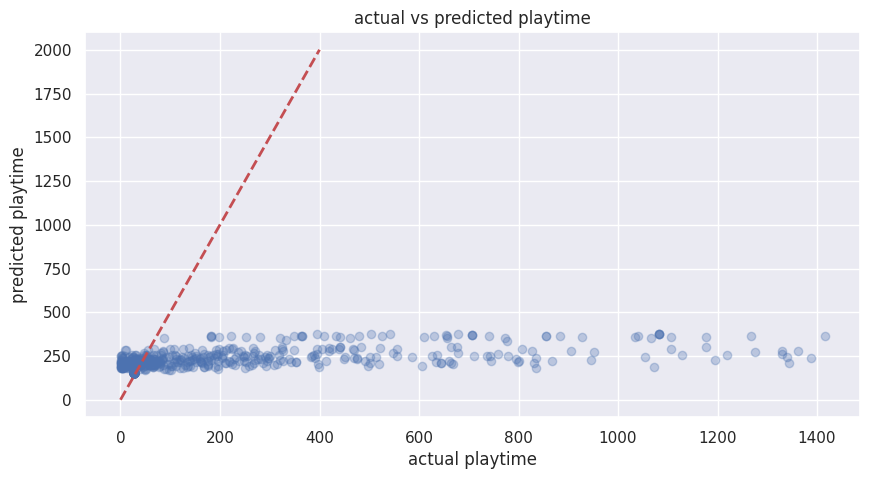

In [42]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([0, 400],
         [0, 2000], 'r--', lw=2)
plt.xlabel("actual playtime")
plt.ylabel("predicted playtime")
plt.title("actual vs predicted playtime")
plt.show()

## Basic (log1p)

In [43]:
def lightGBMObjective(trial):
    # paramaters to hypertune
    n_estimators = trial.suggest_int("n_estimators", 200, 1500)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1)
    num_leaves = trial.suggest_int("num_leaves", 5, 45)
    max_depth = trial.suggest_int("max_depth", 1, 7)
    min_child_samples = trial.suggest_int("min_child_samples", 20, 200)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)
    bagging_fraction = trial.suggest_float("bagging_fraction", 0.6, 0.8)
    feature_fraction = trial.suggest_float("feature_fraction", 0.6, 0.9)

    # lightgbm regression
    regr = LGBMRegressor(
        boosting_type="gbdt",
        n_estimators=n_estimators,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        max_depth=max_depth,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        bagging_fraction=bagging_fraction,
        feature_fraction=feature_fraction,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # precision is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(regr, X_train, y_train_log, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_light = optuna.create_study(direction="minimize")
study_light.optimize(lightGBMObjective, n_trials=50) #increase if have time
best_params_light = study_light.best_params

# print best parameters
print("Best hyperparameters:", best_params_light)
print("Best average precision:", study_light.best_value)

[I 2025-11-24 18:34:17,148] A new study created in memory with name: no-name-ac3e5aaa-b595-4448-9450-1c38a3347a69
[I 2025-11-24 18:34:17,702] Trial 0 finished with value: -1.6416459628121427 and parameters: {'n_estimators': 199, 'learning_rate': 0.04875518617088456, 'num_leaves': 14, 'max_depth': 15, 'min_child_samples': 59, 'reg_alpha': 0.8240299392381804, 'reg_lambda': 2.8705448007458614, 'bagging_fraction': 0.7929786888283459, 'feature_fraction': 0.8830357690723329}. Best is trial 0 with value: -1.6416459628121427.
[I 2025-11-24 18:34:17,829] Trial 1 finished with value: -1.63512513776199 and parameters: {'n_estimators': 30, 'learning_rate': 0.09964181883988373, 'num_leaves': 6, 'max_depth': 5, 'min_child_samples': 96, 'reg_alpha': 0.2951219181941377, 'reg_lambda': 2.8843373496984603, 'bagging_fraction': 0.7950762557472684, 'feature_fraction': 0.665012758032459}. Best is trial 0 with value: -1.6416459628121427.
[I 2025-11-24 18:34:18,073] Trial 2 finished with value: -1.609469713181

Best hyperparameters: {'n_estimators': 34, 'learning_rate': 0.010542364939560149, 'num_leaves': 23, 'max_depth': 1, 'min_child_samples': 182, 'reg_alpha': 0.044430576971073735, 'reg_lambda': 8.810613000256307, 'bagging_fraction': 0.6136255881906582, 'feature_fraction': 0.6519074377360476}
Best average precision: -2.251047311852905


In [44]:
# refit model based on best parameters
regr_light_iqr_log = LGBMRegressor(
        boosting_type="gbdt",
        **best_params_light,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_light_iqr_log,
    X_train,
    y_train_log,
    cv=kf
)

regr_light_iqr_log.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_light_iqr_log.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['LGBM IQR (log)'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# to draw PR_AUC later on
y_test_pred_light_iqr_log = y_test_pred


TRAIN METRICS:
MSE: 2.2510473118529055
RMSE: 1.5003490633358978
R2: 0.09484862724488075
MAE: 1.2427145126700614

TEST METRICS:
MSE: 2.189333912597656
RMSE: 1.4796397915025319
R2: 0.11101431219301283
MAE: 1.2318720835449022


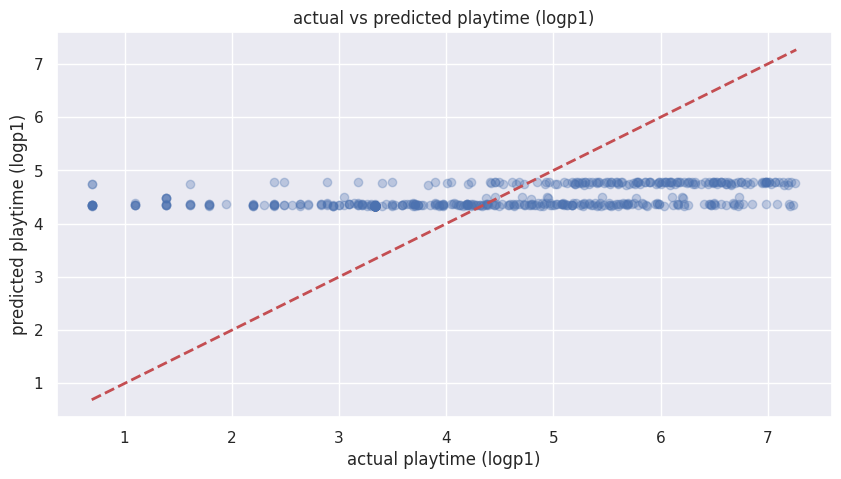

In [45]:
#plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_test_pred, alpha=0.3)
plt.plot([np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()],
         [np.log1p(reg_df[TARGET_COL]).min(), np.log1p(reg_df[TARGET_COL]).max()], 'r--', lw=2)
plt.xlabel("actual playtime (logp1)")
plt.ylabel("predicted playtime (logp1)")
plt.title("actual vs predicted playtime (logp1)")
plt.show()

# Performance Measure Comparison

In [84]:
print("y value range: ", y_min, y_max)
print("y value range IQR: ", y_min_iqr, y_max_iqr)
print("y_log value range: ", y_min_log, y_max_log)
print("y_log value range IQR: ", y_min_IQR_log, y_max_IQR_log)
reg_performance.head()

y value range:  1 10996
y value range IQR:  1 1430
y_log value range:  0.6931471805599453 9.305377787310935
y_log value range IQR:  0.6931471805599453 7.266128779556451


,XGBoost,XGB (log1p),LightGBM,LGBM (log1p),XGB IQR,XGB IQR (log),LGBM IQR,LGBM IQR (log)
Metric,,,,,,,,
MSE,699840.125000,2.037661,707481.033456,2.639739,63905.773438,1.741546,78075.910743,2.189334
RMSE,836.564477,1.427466,841.118918,1.624727,252.795913,1.319676,279.420670,1.479640
R2,0.025635,0.291210,0.014997,0.081780,0.327806,0.292840,0.178757,0.111014
MAE,371.790894,0.992719,392.477488,1.332941,159.392258,0.984731,199.794379,1.231872


# Evaluation

In [85]:
#identify important features
#rename models first - forgot to do that
print("important features:")
feature_importances = pd.Series(regr_xgb_iqr_log.feature_importances_, index=X_train.columns)
print(feature_importances.nlargest(20))

important features:
Linux                        0.071932
Remote Play on TV            0.046871
Online Co-op                 0.034864
RPG                          0.025402
voice_acting                 0.023570
Co-op                        0.022865
Indie                        0.020994
Strategy                     0.017861
HDR available                0.017813
Family Sharing               0.017683
midpoint_estimated_owners    0.016652
Mac                          0.015590
Remote Play on Phone         0.015221
Free to Play                 0.015141
Steam Cloud                  0.013400
DLC count                    0.013166
blood_and_gore               0.012704
blood                        0.012674
esrb_age                     0.012647
Early Access                 0.012420
dtype: float32


In [86]:
import shap

explainer = shap.TreeExplainer(regr_xgb_iqr_log)
shap_values = explainer(X_test)

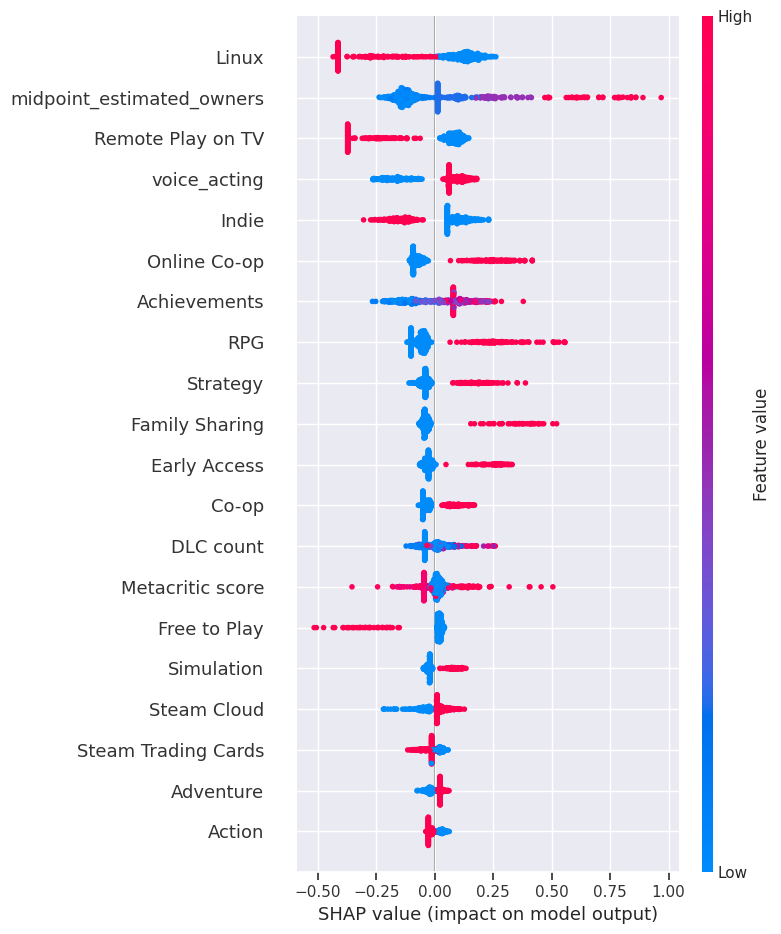

In [88]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20
)

# Ablation

In [79]:
# drop peak CCU since it makes sense that players would pick popular
X_train = X_train.drop(columns=["Peak CCU", "Price", "release_year", "Recommendations", "%_positive_reviews", "midpoint_estimated_owners", "Metacritic score", "User score"])
X_test = X_test.drop(columns=["Peak CCU", "Price", "release_year", "Recommendations", "%_positive_reviews", "midpoint_estimated_owners", "Metacritic score", "User score"])

In [ ]:
# running xgboost again
from xgboost import XGBRegressor

def xgboostObjective(trial):
    # paramaters to hypertune
    eval_metric = trial.suggest_categorical("eval_metric", ["rmse", "mae", "rmsle"])
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    max_delta_step = trial.suggest_int("max_delta_step", 0, 10)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
    subsample = trial.suggest_float("subsample", 0.1, 1)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1)
    reg_alpha = trial.suggest_float("reg_alpha", 0, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0, 10)

    # xgboost classifier
    reg_xgb = XGBRegressor(
        objective="reg:squarederror",
        eval_metric=eval_metric,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        max_delta_step=max_delta_step,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
    )

    # MSE is the best metric for such an imbalanced dataset
    mse_score = cross_val_score(reg_xgb, X_train, y_train_log, cv=kf, scoring="neg_mean_squared_error").mean()

    return mse_score

# Utilize Optuna to obtain the best parameters
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgboostObjective, n_trials=15) #increase if have time
best_params_xgb = study_xgb.best_params

# print best parameters
print("Best hyperparameters:", best_params_xgb)
print("Best negative MSE:", study_xgb.best_value)

In [ ]:
# refit model based on best parameters
regr_xgb = XGBRegressor(
        objective="reg:squarederror",
        **best_params_xgb,
        random_state=42,
        n_jobs=-1
)

y_train_pred = cross_val_predict(
    regr_xgb,
    X_train,
    y_train_log,
    cv=kf
)

regr_xgb.fit(X_train, y_train_log)

# Evaluate training data
print("\nTRAIN METRICS:")
print("MSE:", mean_squared_error(y_train_log, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_log, y_train_pred)))
print("R2:", r2_score(y_train_log, y_train_pred))
print("MAE:", mean_absolute_error(y_train_log, y_train_pred))

# Evaluate test data
y_test_pred = regr_xgb.predict(X_test)

print("\nTEST METRICS:")
print("MSE:", mean_squared_error(y_test_log, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, y_test_pred)))
print("R2:", r2_score(y_test_log, y_test_pred))
print("MAE:", mean_absolute_error(y_test_log, y_test_pred))

# Store performance for comparison later
reg_performance['Random Forest'] = [
    mean_squared_error(y_test_log, y_test_pred),
    np.sqrt(mean_squared_error(y_test_log, y_test_pred)),
    r2_score(y_test_log, y_test_pred),
    mean_absolute_error(y_test_log, y_test_pred)
]

# Save predictions for plotting later if needed
y_test_pred_xgb = y_test_pred

In [ ]:
#identify important features
print("important features:")
feature_importances = pd.Series(regr_xgb.feature_importances_, index=X_train.columns)
print(feature_importances.nlargest(20))

# Can we improve the best model?

## Transformed Regressor

In [62]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer
import numpy as np

log_transformer = FunctionTransformer(np.log1p, np.expm1, validate=False)

def xgboostObjective(trial):
    # parameters to tune
    learning_rate=trial.suggest_float("learning_rate", 0.0001, 0.3, log=True)
    max_depth=trial.suggest_int("max_depth", 3, 6)
    min_child_weight=trial.suggest_int("min_child_weight", 1, 20)
    gamma=trial.suggest_float("gamma", 0, 10)
    subsample=trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0)
    reg_alpha=trial.suggest_float("reg_alpha", 0, 10)
    reg_lambda=trial.suggest_float("reg_lambda", 0, 10)
    n_estimators=trial.suggest_int("n_estimators", 300, 2000)

    model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            eval_metric="mae",
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_child_weight=min_child_weight,
            gamma=gamma,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            random_state=42,
            n_jobs=-1,
        )

    # Wrap in TransformedTargetRegressor so optuna optimizes RMSE in original units
    ttr_model = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )

    # Cross-validated RMSE on **original scale**
    rmse = -cross_val_score(
        ttr_model,
        X_train,
        y_train,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return rmse


study = optuna.create_study(direction="minimize")
study.optimize(xgboostObjective, n_trials=50)

print("Best params:")
print(study.best_params)
print("\nBest CV RMSE:", study.best_value)

best_params = study.best_params


[I 2025-11-24 19:06:24,902] A new study created in memory with name: no-name-3351694f-9863-4df2-95d1-0a7d7fb1df8f
[I 2025-11-24 19:06:36,288] Trial 0 finished with value: 262.37957458496095 and parameters: {'learning_rate': 0.024552835810117003, 'max_depth': 5, 'min_child_weight': 18, 'gamma': 0.0869401166188466, 'subsample': 0.9329186914980351, 'colsample_bytree': 0.8247559642011804, 'reg_alpha': 4.745167439478167, 'reg_lambda': 6.366579222926124, 'n_estimators': 1208}. Best is trial 0 with value: 262.37957458496095.
[I 2025-11-24 19:06:38,858] Trial 1 finished with value: 299.17689819335936 and parameters: {'learning_rate': 0.002213430319524679, 'max_depth': 4, 'min_child_weight': 18, 'gamma': 7.695033964070715, 'subsample': 0.8313967770501268, 'colsample_bytree': 0.8744441139133192, 'reg_alpha': 5.566068042422099, 'reg_lambda': 0.17116544072829032, 'n_estimators': 409}. Best is trial 0 with value: 262.37957458496095.
[I 2025-11-24 19:06:44,794] Trial 2 finished with value: 269.15650

Best params:
{'learning_rate': 0.029986931652799524, 'max_depth': 6, 'min_child_weight': 15, 'gamma': 0.5623434904421815, 'subsample': 0.7784268538492958, 'colsample_bytree': 0.9780378518993236, 'reg_alpha': 6.085847089806858, 'reg_lambda': 2.509452458765566, 'n_estimators': 654}

Best CV RMSE: 260.40550537109374


In [63]:
final_xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    eval_metric="rmse",
    tree_method="hist",
    **best_params
)

model_ttr = TransformedTargetRegressor(
    regressor=final_xgb,
    func=np.log1p,
    inverse_func=np.expm1
)

model_ttr.fit(X_train, y_train)

y_train_pred = model_ttr.predict(X_train)
y_test_pred = model_ttr.predict(X_test)

print("\nTRAIN PERFORMANCE:")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("\nTEST PERFORMANCE:")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

# Save predictions for later
y_test_pred_transformed = y_test_pred


TRAIN PERFORMANCE:
MSE: 41304.2734375
RMSE: 203.23452816266237
MAE: 100.2975845336914
R2: 0.5220792293548584

TEST PERFORMANCE:
MSE: 71500.546875
RMSE: 267.39586173873374
MAE: 145.38063049316406
R2: 0.2479204535484314


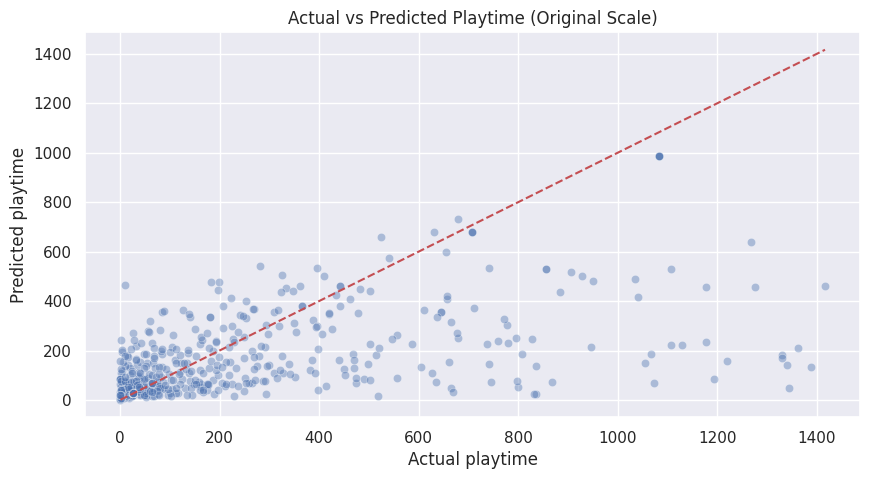

In [66]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual playtime")
plt.ylabel("Predicted playtime")
plt.title("Actual vs Predicted Playtime (Original Scale)")
plt.show()